In [1]:
import numpy as np
from scipy.stats import spearmanr


def mean_se(data):
    mean = np.mean(data)
    se = np.std(data) / np.sqrt(len(data))
    return mean, se

In [2]:
# lunarlander

supervised_regret = [20, 0, 248, 0, 20]
q_regret = [0, 20.2, 0, 6, 3.6]
hinge_regret = [3.5, 3.7, 0, 6, 0]
kendall_regret = [0, 0, 0, 0, 3.6]
listnet_regret = [6, 6, 6, 6, 6]


regrets = {
    'Supervised': supervised_regret,
    'Q-based': q_regret,
    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")

Average Regret:
------------------------------
Supervised  : 57.60 ± 42.76
Q-based     : 5.96 ± 3.34
Hinge       : 2.64 ± 1.04
Kendall     : 0.72 ± 0.64
ListNet     : 6.00 ± 0.00


In [3]:

# True ranking
true_ranking = [5, 3, 4, 2, 1]

# All rankings by estimator and seed
supervised_rankings = [
    [2, 3, 5, 1, 4],  # seed 0
    [5, 4, 2, 3, 1],  # seed 1
    [1, 5, 3, 4, 2],  # seed 2
    [5, 3, 2, 1, 4],  # seed 3
    [2, 5, 3, 4, 1],  # seed 4
]

q_rankings = [
    [5, 3, 4, 2, 1],  # seed 0
    [2, 5, 3, 4, 1],  # seed 1
    [5, 4, 3, 2, 1],  # seed 2
    [4, 5, 3, 2, 1],  # seed 3
    [3, 5, 4, 2, 1],  # seed 4
]

hinge_rankings = [
    [3, 5, 4, 2, 1],  # seed 0
    [3, 2, 5, 4, 1],  # seed 1
    [5, 4, 3, 2, 1],  # seed 2
    [4, 5, 3, 2, 1],  # seed 3
    [5, 3, 4, 2, 1],  # seed 4
]

kendall_rankings = [
    [5, 4, 3, 2, 1],  # seed 0
    [5, 3, 4, 2, 1],  # seed 1
    [5, 4, 3, 2, 1],  # seed 2
    [5, 4, 3, 2, 1],  # seed 3
    [3, 4, 5, 2, 1],  # seed 4
]

listnet_rankings = [
    [4, 5, 3, 2, 1],  # seed 0
    [4, 5, 2, 3, 1],  # seed 1
    [4, 3, 5, 2, 1],  # seed 2
    [4, 5, 3, 2, 1],  # seed 3
    [4, 3, 5, 2, 1],  # seed 4
]

# Calculate average Spearman correlation for each estimator
def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Q-based': q_rankings,
    'Hinge': hinge_rankings,
    'Kendall': kendall_rankings,
    'ListNet': listnet_rankings,
}

print("Average Spearman's Correlation with True Ranking:")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking:
--------------------------------------------------
Supervised  : 0.160 ± 0.149
Q-based     : 0.660 ± 0.140
Hinge       : 0.740 ± 0.083
Kendall     : 0.880 ± 0.044
ListNet     : 0.740 ± 0.067


In [4]:
# lunarlander, nll loss, lambda 0.5, patience 50

supervised_regret = [251, 251, 6, 3.7, 20]
q_regret = [6,6,6,6,6]
hinge_regret = [0, 0, 0, 6, 3.7]
kendall_regret = [0, 0, 0, 0, 20]
listnet_regret = [0, 20, 20, 20, 3.7]

regrets = {
    'Supervised': supervised_regret,
    'Q-based': q_regret,
    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")


Average Regret:
------------------------------
Supervised  : 106.34 ± 52.88
Q-based     : 6.00 ± 0.00
Hinge       : 1.94 ± 1.11
Kendall     : 4.00 ± 3.58
ListNet     : 12.74 ± 4.01


In [5]:
from scipy.stats import spearmanr

# True ranking
true_ranking = [5, 3, 4, 2, 1, 0]

supervised_rankings = [
    [4,3,5,2,1,0],  
    [3,5,2,1,4,0], 
    [2,1,4,5,3,0],  
    [1,4,5,2,3,0],  
    [1,4,5,2,3,0],  
]

q_rankings = [
    [4,3,5,2,1,0],  
    [4,3,5,2,1,0],   
    [4,3,5,2,1,0],  
    [4,3,5,2,1,0],  
    [4,3,5,2,1,0],  
]

hinge_rankings = [
    [5,3,2,4,1,0],  
    [4,5,2,3,1,0],  
    [5,4,3,2,1,0],  
    [5,4,3,2,1,0],  
    [3,4,5,2,1,0],  
]

kendall_rankings = [
    [5,4,2,3,1,0],  
    [5,2,3,4,1,0],  
    [5,2,3,4,1,0],  
    [5,3,4,2,1,0],  
    [3,2,4,5,1,0],  
]

listnet_rankings = [
    [5,4,3,2,1,0],  
    [2,4,5,3,1,0],  
    [3,2,5,4,1,0],  
    [2,4,3,5,1,0],  
    [2,5,1,4,3,0],  
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Q-based': q_rankings,
    'Hinge': hinge_rankings,
    'Kendall': kendall_rankings,
    'ListNet': listnet_rankings,
}

print("Average Spearman's Correlation with True Ranking:")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking:
--------------------------------------------------
Supervised  : 0.463 ± 0.109
Q-based     : 0.943 ± 0.000
Hinge       : 0.840 ± 0.041
Kendall     : 0.817 ± 0.057
ListNet     : 0.577 ± 0.122


In [6]:
# lunarlander, mse loss, lambda 0.1, patience 200

supervised_regret = [6.3, 6.3, 70, 1.1, 1.1]
kendall_regret = [6.3, 0, 0, 0, 0]

regrets = {
    'Supervised': supervised_regret,
    'Kendall': kendall_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")


Average Regret:
------------------------------
Supervised  : 16.96 ± 11.91
Kendall     : 1.26 ± 1.13


In [8]:
from scipy.stats import spearmanr

# True ranking
true_ranking = [5, 4, 3, 2, 1]

supervised_rankings = [
    [3,2,4,5,1],  
    [3,4,5,2,1], 
    [4,3,2,1,5],  
    [2,5,4,3,1],  
    [4,3,5,2,1],  
]

kendall_rankings = [
    [4,3,2,5,1],  
    [5,4,3,2,1],  
    [5,4,3,2,1],  
    [5,4,3,2,1],  
    [5,4,3,2,1],  
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Kendall': kendall_rankings,
}

print("Average Spearman's Correlation with True Ranking:")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking:
--------------------------------------------------
Supervised  : 0.360 ± 0.122
Kendall     : 0.880 ± 0.107


In [15]:
# pendulum

# 75.3

supervised_regret = [0.64,0.23,0.27,0.3, 0.35]
q_regret = [0.05, 0.23, 0.27, 0.14, 0.09]
hinge_regret = [0.05, 0.23, 0.05, 0.58, 0.09]
kendall_regret = [0.05, 0.64, 0.05, 0.14, 0.09]
listnet_regret = [0.05, 0.64, 0,0, 0.09]  

In [16]:
def mean_se(data):
    mean = np.mean(data)
    se = np.std(data) / np.sqrt(len(data))
    return mean, se

regrets = {
    'Supervised': supervised_regret,
    'Q-based': q_regret,
    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")

Average Regret:
------------------------------
Supervised  : 0.36 ± 0.07
Q-based     : 0.16 ± 0.04
Hinge       : 0.20 ± 0.09
Kendall     : 0.19 ± 0.10
ListNet     : 0.16 ± 0.11


In [17]:
true_ranking = [5,4,3,2,1,0]

supervised_rankings = [
    [2,4,3,5,1,0],
    [3,1,5,4,2,0],
    [3,2,4,5,1,0],
    [3,2,4,5,1,0],
    [3,4,2,5,1,0]
]
q_rankings = [
    [3,4,5,2,1,0],
    [3,4,2,5,1,0],
    [3,4,5,2,1,0],
    [4,2,5,3,1,0],
    [4,3,2,5,1,0]
]
hinge_rankings = [
    [4,5,2,3,1,0],
    [3,4,2,5,1,0],
    [4,5,3,2,1,0],
    [2,4,5,1,3,0],
    [4,3,5,2,1,0]
]
kendall_rankings = [
    [4,5,3,2,1,0],
    [2,4,5,1,3,0],
    [4,3,5,2,1,0],
    [4,5,3,2,1,0],
    [4,5,3,2,1,0]
]
listnet_rankings = [
    [4,3,5,2,1,0],
    [2,3,4,5,1,0],
    [5,4,3,2,1,0],
    [5,3,4,2,1,0],
    [4,5,3,1,2,0]
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Q-based': q_rankings,
    'Hinge': hinge_rankings,
    'Kendall': kendall_rankings,
    'ListNet': listnet_rankings,
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.486 ± 0.032
Q-based     : 0.703 ± 0.030
Hinge       : 0.749 ± 0.079
Kendall     : 0.829 ± 0.079
ListNet     : 0.817 ± 0.091


In [28]:
# pendulum nll


supervised_regret = [0.3, 0.6, 0, 0.14]
q_regret = [0, 0, 0.14, 0.14, 0.6]
hinge_regret = [0,0.14,0.3,0.3,0]
kendall_regret = [0, 0, 0.14, 0, 0]
listnet_regret = [0,0.3,0.14,0.3,0]

regrets = {
    'Supervised': supervised_regret,
    'Q-based': q_regret,
    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")


Average Regret:
------------------------------
Supervised  : 0.26 ± 0.11
Q-based     : 0.18 ± 0.10
Hinge       : 0.15 ± 0.06
Kendall     : 0.03 ± 0.03
ListNet     : 0.15 ± 0.06


In [29]:
true_ranking = [5,4,3,2,1,0]

supervised_rankings = [
    [3,5,4,2,1,0],
    [5,2,3,4,1,0],
    [2,3,4,5,1,0],
    [4,1,5,3,2,0]
]
q_rankings = [
    [5,4,3,2,1,0],
    [5,3,4,2,1,0],
    [4,5,3,2,1,0],
    [4,3,5,2,1,0],
    [2,3,5,4,1,0]
]
hinge_rankings = [
    [4,3,5,2,1,0],
    [5,3,4,2,1,0],
    [3,2,4,5,1,0],
    [3,5,2,4,1,0],
    [5,3,1,2,4,0]
]
kendall_rankings = [
    [5,3,2,4,1,0],
    [5,3,4,2,1,0],
    [4,5,3,2,1,0],
    [5,4,3,2,1,0],
    [5,3,4,2,1,0]
]
listnet_rankings = [
    [5,4,3,1,2,0],
    [3,5,4,1,2,0],
    [3,4,2,5,1,0],
    [4,3,5,1,2,0],
    [5,4,3,2,1,0]
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))  # Standard error
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Q-based': q_rankings,
    'Hinge': hinge_rankings,
    'Kendall': kendall_rankings,
    'ListNet': listnet_rankings,
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.643 ± 0.082
Q-based     : 0.840 ± 0.083
Hinge       : 0.714 ± 0.072
Kendall     : 0.931 ± 0.025
ListNet     : 0.817 ± 0.063


In [ ]:
#ghaffari cancer (continuous) nll base loss (seeds 26-30)

# lunarlander

supervised_regret = [0,0,0,0,65.7]
#q_regret = []
#hinge_regret = [3.5, 3.7, 0, 6, 0]
kendall_regret = [0,0,0,0,0]
#listnet_regret = [6, 6, 6, 6, 6]


regrets = {
    'Supervised': supervised_regret,
#    'Q-based': q_regret,
#    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
#    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")

Average Regret:
------------------------------
Supervised  : 13.14 ± 11.75
Kendall     : 0.00 ± 0.00


In [9]:
true_ranking = [5,4,3,2,1]

supervised_rankings = [
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [1,2,5,3,4],
    [5,4,3,2,1],
]
kendall_rankings = [
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Kendall': kendall_rankings,
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.660 ± 0.304
Kendall     : 1.000 ± 0.000


In [ ]:
#ghaffari cancer (continuous) mse base loss (seeds 21-25)

supervised_regret = [59.6, 23.5, 0, 0, 59.3]
#q_regret = []
#hinge_regret = [3.5, 3.7, 0, 6, 0]
kendall_regret = [27.5, 0, 0, 0, 0]
#listnet_regret = [6, 6, 6, 6, 6]


regrets = {
    'Supervised': supervised_regret,
#    'Q-based': q_regret,
#    'Hinge': hinge_regret,
    'Kendall': kendall_regret,
#    'ListNet': listnet_regret,
}

print("Average Regret:")
print("-" * 30)
for name, regret in regrets.items():
    mean, se = mean_se(regret)
    print(f"{name:12s}: {mean:.2f} ± {se:.2f}")

Average Regret:
------------------------------
Supervised  : 28.48 ± 11.94
Kendall     : 5.50 ± 4.92


In [7]:
true_ranking = [5,4,3,2,1]

supervised_rankings = [
    [3,4,2,5,1],
    [2,5,3,4,1],
    [5,3,4,2,1],
    [5,4,3,2,1],
    [2,5,4,3,1],
]
kendall_rankings = [
    [4,2,5,3,1],
    [5,3,4,2,1],
    [5,4,3,2,1],
    [5,4,3,2,1],
    [5,3,4,2,1],
]

def avg_spearman(rankings, true_ranking):
    correlations = [spearmanr(r, true_ranking).correlation for r in rankings]
    mean = np.mean(correlations)
    std = np.std(correlations)
    se = std / np.sqrt(len(correlations))
    return mean, se

estimators = {
    'Supervised': supervised_rankings,
    'Kendall': kendall_rankings,
}

print("Average Spearman's Correlation with True Ranking (Pendulum):")
print("-" * 50)
for name, rankings in estimators.items():
    mean_corr, se_corr = avg_spearman(rankings, true_ranking)
    print(f"{name:12s}: {mean_corr:.3f} ± {se_corr:.3f}")

Average Spearman's Correlation with True Ranking (Pendulum):
--------------------------------------------------
Supervised  : 0.580 ± 0.137
Kendall     : 0.860 ± 0.083


In [6]:
#different lambda rank mse in cancer (mse base)
supervised_train_mse = [0.237, 0.242, 0.256, 0.343, 0.396]
supervised_test_mse = [0.278, 0.185, 0.162, 0.284, 0.264]

kendell_01_train_mse = [0.236, 0.240, 0.251, 0.335, 0.387]
kendell_01_test_mse = [0.280, 0.188, 0.160, 0.275, 0.259]

kendell_02_train_mse = [0.232, 0.442, 0.246, 0.338, 0.373]
kendell_02_test_mse = [0.279, 0.292, 0.153, 0.275, 0.253]

kendell_03_train_mse = [0.241, 0.249, 0.254, 0.333, 0.396]
kendell_03_test_mse = [0.285, 0.189, 0.161, 0.276, 0.262]

kendell_04_train_mse = [0.234, 0.238, 0.254, 0.336, 0.397]
kendell_04_test_mse = [0.278, 0.188, 0.159, 0.278, 0.256]

kendell_05_train_mse = [0.251, 0.277, 0.242, 0.387, 0.429]
kendell_05_test_mse = [0.301, 0.200, 0.155, 0.315, 0.288]

kendell_06_train_mse = [0.237, 0.444, 0.273, 0.340, 0.422]
kendell_06_test_mse = [0.285, 0.292, 0.174, 0.280, 0.281]

kendell_07_train_mse = [0.384, 0.280, 0.264, 0.349, 0.422] #not done the 5th
kendell_07_test_mse = [0.401, 0.203, 0.162, 0.293, 0.281]

kendell_08_train_mse = [0.259, 0.278, 0.237, 0.355, 0.452] 
kendell_08_test_mse = [0.307, 0.204, 0.158, 0.293, 0.310]

kendell_09_train_mse = [0.370, 0.247, 0.358, 0.348, 0.553] 
kendell_09_test_mse = [0.386, 0.189, 0.259, 0.288, 0.392]

kendell_1_train_mse = [0.414, 0.462, 0.404, 0.579, 0.638] 
kendell_1_test_mse = [0.427, 0.305, 0.286, 0.413, 0.454]

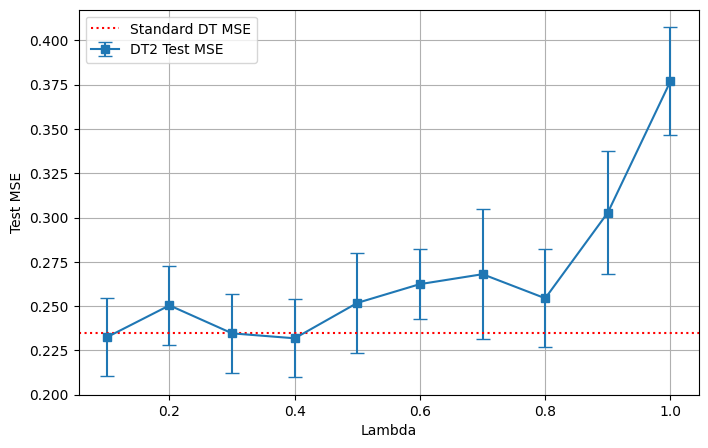

In [11]:
import matplotlib.pyplot as plt
import numpy as np

lambdas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

def mean_se(data):
    mean = np.mean(data)
    se = np.std(data) / np.sqrt(len(data))
    return mean, se

# Compute averages and standard errors for each lambda value
kendall_test_means = []
kendall_test_ses = []

test_mse_list = [
    kendell_01_test_mse,
    kendell_02_test_mse,
    kendell_03_test_mse,
    kendell_04_test_mse,
    kendell_05_test_mse,
    kendell_06_test_mse,
    kendell_07_test_mse,
    kendell_08_test_mse,
    kendell_09_test_mse,
    kendell_1_test_mse,
]

for test in test_mse_list:
    mean_te, se_te = mean_se(test)
    kendall_test_means.append(mean_te)
    kendall_test_ses.append(se_te)

# Calculate averages for supervised baselines
supervised_test_avg = np.mean(supervised_test_mse)

plt.figure(figsize=(8, 5))
plt.errorbar(lambdas, kendall_test_means, yerr=kendall_test_ses, marker='s', label='DT2 Test MSE', capsize=5)
plt.axhline(supervised_test_avg, color='red', linestyle=':', label='Standard DT MSE')
plt.xlabel('Lambda')
plt.ylabel('Test MSE')
plt.legend()
plt.grid(True)
plt.savefig('lambda_cancer_mse.pdf')
